<b><font size="6" color="#f35b1f">Week 5: Hyperparameter Tuning </font></b><br>

In week 4 the pipeline learned to **evaluate** a model honestly: a locked test set, and stratified 5-fold cross-validation of the whole pipeline on the development set. Every model was run with **default** hyperparameters, and the decision tree came out overfitting (train ≫ validation) and losing to logistic regression.

Is that the tree, or its defaults? To answer, we have to **choose hyperparameters** - and choosing is a decision, so it follows the same rules as every other decision: development set only, every candidate scored by CV of the whole pipeline, and an honest number at the end. This notebook:

1. opens up the decision tree's main hyperparameter, **`max_depth`**, and shows how it controls overfitting;
2. shows the ways tuning quietly leaks, and the one that survives even a perfect pipeline - **the best score is optimistic**;
3. tunes the tree with **Optuna**, leak-free, the way the pipeline does it;
4. measures the tuning procedure honestly with **nested cross-validation**.

**See it here first, then add it to the pipeline.** As in week 4, every function is written out and run here — **character for character the same code** as the pipeline, with the arguments `main.py` passes. To keep it clear what is old and what is new:

- **Already in your pipeline** (weeks 2–4): all collected in **one cell** in Section 1.3. Run it and move on.
- **New this week** (`src/tuning.py`): each one appears in a green box, and is first shown **step by step, by hand**, before the function that packages those steps.

**This notebook runs on its own.** The configuration is written out in the notebook (Section 1.2, a copy of the pipeline's `config.yaml`), so it runs the same for everyone, even if you've already changed your own `config.yaml`. Only the data file is read from the pipeline folder (`PIPELINE_DIR`).

<div class="alert alert-block alert-info">

## Table of Contents<a class="anchor" id="toc"></a>
### [<font color='#f35b1f'>1 - Setup: The Pipeline So Far</font>](#setup)
### [<font color='#f35b1f'>2 - Parameters vs Hyperparameters: Inside the Decision Tree</font>](#dt)
* [2.1 - `max_depth` and overfitting](#depth) · [2.2 - What a deep tree memorises](#leaves) 
### [<font color='#f35b1f'>3 - How Tuning Leaks</font>](#leaks)
* [3.1 - Three mistakes](#mistakes) · [3.2 - The winner's curse](#curse)
### [<font color='#f35b1f'>4 - Search Strategies and Optuna</font>](#optuna)
* [4.1 - How Optuna works](#how-optuna) · [4.2 - How TPE chooses the next trial](#tpe) · [4.3 - The search space](#space)
### [<font color='#f35b1f'>5 - Tuning the Tree the Right Way</font>](#tuning)
### [<font color='#f35b1f'>6 - Nested Cross-Validation: An Honest Number for a Tuned Model</font>](#nested)
* [6.1 - The idea](#nested-idea) · [6.2 - Running it](#nested-run) 
### [<font color='#f35b1f'>7 - Adding Tuning to Your Pipeline</font>](#pipeline)
### [<font color='#f35b1f'>Key Takeaways · README · Challenges</font>](#takeaways)
</div>

## <font color='#f35b1f'>1. Setup: The Pipeline So Far</font> <a class="anchor" id="setup"></a>
[Back to TOC](#toc)

In [7]:
# Install the packages this notebook needs (skip if your environment already has them)
# !pip install -q pandas numpy "scikit-learn>=1.9" PyYAML category-encoders matplotlib optuna
# NEW this week: optuna. In your PIPELINE, add "optuna>=4.0" to requirements.txt and re-run
# !pip install -r requirements.txt with the venv active -- see Section 7, Step 0.

In [9]:
import copy
import time
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yaml
from pprint import pprint
import matplotlib.pyplot as plt
import matplotlib as mpl
import optuna
from sklearn.base import BaseEstimator, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, TargetEncoder, StandardScaler, MinMaxScaler, RobustScaler,
)
from category_encoders import CountEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, get_scorer
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)      # no line per trial
pd.set_option("display.width", 160)
BLUE, ORANGE, GRAY, GREEN, LIGHT = "#1B6FA8", "#f35b1f", "#6B7280", "#6CD69A", "#9CC3E0"
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["font.size"] = 10.5

### 1.1 · The pipeline map

What `python main.py` does, and where each step lives. The rule behind it: **anything that learns from data lives inside the sklearn `Pipeline`**, and the `Pipeline` lives inside cross-validation.

| Step in `main.py` | Function | File | Learns from data? | |
|---|---|---|---|---|
| load | `load_data()` | `src/data.py` | no | already in your pipeline |
| clean (row-preserving) | `clean_dataset()` | `src/preprocessing.py` | no - fixed rules from the config | already in your pipeline |
| de-duplicate (training data only) | `drop_duplicate_rows()` | `src/preprocessing.py` | no | already in your pipeline |
| features / target | `split_features_target()` | `src/preprocessing.py` | no | already in your pipeline |
| **lock the test set** | `split_dev_test()` | `src/preprocessing.py` | from here on: development set only | already in your pipeline |
| preprocessing + model = **one** estimator | `build_pipeline()` → `Pipeline([("prep", build_preprocessor()), ("model", build_model())])` | `src/model.py` | **yes** - imputer, encoder, scaler, model: re-fit in every fold |  **moved into a function this week** (Section 1.4) |
| evaluate | `cross_validate_pipeline()`, `cv_report()` | `src/evaluate.py` | fits the Pipeline once per fold | already in your pipeline |
| **tune + nested CV** | `tune_pipeline()`, `nested_cross_validate()`, `tuning_report()` | **`src/tuning.py`** | fits the Pipeline once per fold, **per trial** |  **new this week** |
| reports | `oof_classification_report()`, `fairness_report()` | `src/evaluate.py` | no | already in your pipeline |
| final model | `pipeline.fit(X_dev, y_dev)` | `main.py` | yes - on all development rows | already in your pipeline (now tuned) |

### 1.2 · The configuration - written out here

These cells are a **copy of the pipeline's `config.yaml`**, comments included, parsed into the same `config` dictionary that `main.py` gets from `load_config()`. Writing it here, instead of reading your file, means this notebook always runs, and always gives the numbers in this notebook, whatever you change in your own pipeline. When you want to try something (a different depth range, more trials), change it **here**, in the notebook's copy.

The sections from weeks 2-4 - unchanged:

In [10]:
# ---- config.yaml -- the sections from weeks 2-4, exactly as in the pipeline ----
config = yaml.safe_load("""
data:
  path: "data/compas_two_year_recidivism.csv"
  target: "two_year_recid"
  sensitive_attr: "race"                            # never a feature; used only for the fairness report
  drop_columns: ["id", "decile_score", "score_text"]  # kept in the data, never used as features

# Locked test set: never used to fit, tune or choose anything. Do not change once set.
test_set:
  size: 0.2
  random_state: 42

cv:
  n_splits: 5
  shuffle: true
  random_state: 42
  scoring: "accuracy"
  n_jobs: 1                                         # -1 = all CPU cores

diagnostics:
  id_column: "id"
  numeric_text_columns: ["priors_count", "prior_offenses"]
  # "nan" catches real NaNs turned into text by the category cleanup.
  placeholder_tokens: ["-", "?", "n/a", "N/A", "na", "NA", "", "nan"]
  validity_rules:
    age: {min: 18, max: 100}
    decile_score: {min: 1, max: 10}
    juv_fel_count: {min: 0}
    priors_count: {min: 0, max: 60}
  canonical_categories:
    sex:
      male: "Male"
      female: "Female"
    race:
      african-american: "African-American"
      african american: "African-American"
      caucasian: "Caucasian"
      hispanic: "Hispanic"
      other: "Other"
      asian: "Asian"
      native american: "Native American"
    c_charge_degree:
      f: "F"
      felony: "F"
      m: "M"
      misdemeanor: "M"
    score_text:
      low: "Low"
      medium: "Medium"
      high: "High"
  redundant_columns: ["prior_offenses", "age_in_months", "juvenile_total"]

preprocessing:
  encoder: "target"                                 # onehot | ordinal | count | target
  scaler: "robust"                                  # none | standard | minmax | robust
  numeric_features: ["age", "juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count"]
  categorical_features: ["sex", "age_cat", "c_charge_degree"]
  mnar_indicator_sources: ["priors_count", "c_charge_degree"]   # get a <col>_was_missing flag
  random_state: 42                                  # target encoder's internal folds
  imputation:
    numeric_strategy: "median"
    categorical_strategy: "most_frequent"
""")
print("sections:", list(config))

sections: ['data', 'test_set', 'cv', 'diagnostics', 'preprocessing']


**Changed this week:** the `model` section. The decision tree replaces logistic regression as the model `main.py` runs, because it's the model whose hyperparameters matter most:

In [11]:
# ---- config.yaml -- CHANGED this week: the model section ----
config.update(yaml.safe_load("""
model:
  type: "decision_tree"                             # dummy | logistic_regression | decision_tree | random_forest
  params:
    random_state: 42
"""))
pprint(config["model"], sort_dicts=False)

{'type': 'decision_tree', 'params': {'random_state': 42}}


The last new section, `tuning`, is added in Section 4, where it's used.

### 1.3 · Already in your pipeline (weeks 2-4)

**One cell, every function the pipeline already had** - copied verbatim from `src/data.py`, `src/preprocessing.py`, `src/model.py` and `src/evaluate.py`. Nothing here is new, and nothing in it changes this week: `02_preprocessing.ipynb` and `03_cross_validation.ipynb` explain them. Run it and move on.

| File | Functions | What they do |
|---|---|---|
| `src/data.py` | `load_data()` | read the CSV |
| `src/preprocessing.py` | `flag_invalid_values()`, `_canonicalize_categories()`, `clean_dataset()` | fixed cleaning rules, row-preserving |
| | `drop_duplicate_rows()` | training data only, before the split |
| | `add_missingness_indicators()`, `split_features_target()` | `_was_missing` flags; X, y and the extras (race, COMPAS score) |
| | `_SCALERS`, `_ENCODERS`, `build_preprocessor()` | the unfitted `ColumnTransformer` (impute → scale / encode) |
| | `split_dev_test()` | the locked test set |
| `src/model.py` | `_MODELS`, `build_model()` | a model from the `model` section |
| `src/evaluate.py` | `cross_validate_pipeline()` | k-fold CV of the whole pipeline: fold table + out-of-fold predictions |
| | `cv_report()`, `oof_classification_report()`, `fairness_report()` | the text reports |

In [12]:
# ---- src/data.py -- already in your pipeline (identical) ----
def load_data(path: str) -> pd.DataFrame:
    """Load the raw dataset from a CSV file."""
    return pd.read_csv(path)


# ---- src/preprocessing.py -- already in your pipeline (identical) ----
def flag_invalid_values(df: pd.DataFrame, rules: dict) -> pd.DataFrame:
    """
    Applies {column: {"min": ..., "max": ...}} domain rules (either bound optional) and sets
    violations to NaN, in place. Returns the number of violations per column.
    """
    report_rows = []
    for column, bounds in rules.items():
        if column not in df.columns:
            continue
        numeric = pd.to_numeric(df[column], errors="coerce")
        lower_ok = numeric >= bounds["min"] if "min" in bounds else pd.Series(True, index=numeric.index)
        upper_ok = numeric <= bounds["max"] if "max" in bounds else pd.Series(True, index=numeric.index)
        violations = numeric.notna() & ~(lower_ok & upper_ok)
        report_rows.append({"column": column, "rule": bounds, "violations": int(violations.sum())})
        df.loc[violations, column] = np.nan
    return pd.DataFrame(report_rows)


def _canonicalize_categories(df: pd.DataFrame, columns_and_maps: dict, placeholder_tokens: set) -> pd.DataFrame:
    out = df.copy()
    for col, mapping in columns_and_maps.items():
        if col not in out.columns:
            continue
        cleaned = out[col].astype(str).str.strip()
        lowered = cleaned.str.lower()
        out[col] = lowered.map(mapping).fillna(cleaned)
        out.loc[out[col].astype(str).str.strip().isin(placeholder_tokens), col] = np.nan
    return out


def clean_dataset(df: pd.DataFrame, diagnostics_config: dict) -> pd.DataFrame:
    """
    Applies the cleaning rules in `diagnostics_config`: placeholder tokens and domain-rule
    violations become NaN, category spellings are canonicalized and redundant columns are
    dropped. Row-preserving and target-agnostic, so it runs unchanged on data to predict.
    """
    out = df.copy()
    placeholder_tokens = set(diagnostics_config.get("placeholder_tokens", []))

    for col in diagnostics_config.get("numeric_text_columns", []):
        if col in out.columns:
            out[col] = pd.to_numeric(out[col].replace(list(placeholder_tokens), np.nan), errors="coerce")

    flag_invalid_values(out, diagnostics_config.get("validity_rules", {}))
    out = _canonicalize_categories(out, diagnostics_config.get("canonical_categories", {}), placeholder_tokens)

    columns_to_drop = [c for c in diagnostics_config.get("redundant_columns", []) if c in out.columns]
    return out.drop(columns=columns_to_drop)


def drop_duplicate_rows(df: pd.DataFrame, id_column: str = None) -> pd.DataFrame:
    """
    Training data only, before `split_dev_test`: drops exact duplicate rows and repeated ids
    (keeping the first). Never call it on data to predict: every row needs a prediction.
    """
    out = df.drop_duplicates()
    if id_column and id_column in out.columns:
        out = out.drop_duplicates(subset=id_column, keep="first")
    return out


def add_missingness_indicators(df: pd.DataFrame, mnar_indicator_sources: list) -> pd.DataFrame:
    """Adds a `<col>_was_missing` flag for each listed column, before it is imputed."""
    out = df.copy()
    for col in mnar_indicator_sources:
        if col in out.columns:
            out[f"{col}_was_missing"] = out[col].isna().astype(int)
    return out


def split_features_target(df: pd.DataFrame, data_config: dict, mnar_indicator_sources: list):
    """
    Returns (X, y, extras). `extras` holds the columns kept out of the features for auditing
    (the sensitive attribute and COMPAS's own score). On label-free data `y` is None.
    """
    target = data_config["target"]
    sensitive_attr = data_config["sensitive_attr"]
    drop_columns = data_config.get("drop_columns", [])

    df = add_missingness_indicators(df, mnar_indicator_sources)
    y = df[target] if target in df.columns else None

    extras_cols = [c for c in [sensitive_attr, "score_text"] if c in df.columns]
    extras = df[extras_cols].copy() if extras_cols else None

    always_drop = set(drop_columns) | {target, sensitive_attr}
    feature_cols = [c for c in df.columns if c not in always_drop]
    return df[feature_cols], y, extras


_SCALERS = {"none": "passthrough", "standard": StandardScaler, "minmax": MinMaxScaler, "robust": RobustScaler}


_ENCODERS = {
    "onehot": lambda seed: OneHotEncoder(handle_unknown="ignore", sparse_output=False),
    "ordinal": lambda seed: OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
    "count": lambda seed: CountEncoder(handle_unknown=0, handle_missing=0),
    "target": lambda seed: TargetEncoder(target_type="binary", cv=StratifiedKFold(5, shuffle=True, random_state=seed)),
}


def build_preprocessor(preprocessing_config: dict) -> ColumnTransformer:
    """
    Builds the unfitted ColumnTransformer described by `preprocessing_config`: imputation and
    scaling for numeric columns, imputation and encoding for categorical ones, and the
    missingness flags passed through. Every encoder tolerates unseen categories.
    """
    imputation = preprocessing_config.get("imputation", {})
    scaler_factory = _SCALERS[preprocessing_config["scaler"]]
    scaler = scaler_factory() if callable(scaler_factory) else scaler_factory
    encoder = _ENCODERS[preprocessing_config["encoder"]](preprocessing_config.get("random_state"))

    numeric_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy=imputation.get("numeric_strategy", "median"))),
        ("scale", scaler),
    ])
    categorical_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy=imputation.get("categorical_strategy", "most_frequent"))),
        ("encode", encoder),
    ])
    indicator_cols = [f"{c}_was_missing" for c in preprocessing_config.get("mnar_indicator_sources", [])]

    return ColumnTransformer([
        ("numeric", numeric_pipeline, preprocessing_config["numeric_features"]),
        ("categorical", categorical_pipeline, preprocessing_config["categorical_features"]),
        ("indicators", "passthrough", indicator_cols),
    ])


def split_dev_test(X, y, extras, test_size: float, random_state: int):
    """
    Stratified split into a development set, used for every decision, and a locked test set,
    used only for the final assessment. Returns X_dev, X_test, y_dev, y_test, extras_dev,
    extras_test, row-aligned.
    """
    return train_test_split(X, y, extras, test_size=test_size, random_state=random_state, stratify=y)


# ---- src/model.py -- already in your pipeline (identical) ----
_MODELS = {
    "dummy": DummyClassifier,
    "logistic_regression": LogisticRegression,
    "decision_tree": DecisionTreeClassifier,
    "random_forest": RandomForestClassifier,
}


def build_model(model_config: dict):
    """Builds the model named by `model_config["type"]` with `model_config["params"]`."""
    model_type = model_config["type"]
    params = model_config.get("params") or {}

    if model_type not in _MODELS:
        raise ValueError(f"Unknown model type: {model_type}. Options: {list(_MODELS)}")

    return _MODELS[model_type](**params)


# ---- src/evaluate.py -- already in your pipeline (identical) ----
def cross_validate_pipeline(pipeline, X, y, cv, scoring: str = "accuracy", n_jobs: int = 1):
    """
    Fits a fresh copy of `pipeline` (preprocessing included) on each fold's training part and
    scores it on that fold's validation part.

    Returns (fold_scores, y_oof):
      - fold_scores: one row per fold with the train score, the validation score and their gap;
      - y_oof: out-of-fold predictions, each row predicted by the fold model that did not
        train on it, taken from the same fits as the scores. `cv` must be a partition
        (each row validated exactly once).
    """
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=True,
                            return_estimator=True, return_indices=True, n_jobs=n_jobs)
    fold_scores = pd.DataFrame({
        "fold": range(1, len(scores["test_score"]) + 1),
        "train": scores["train_score"],
        "validation": scores["test_score"],
    })
    fold_scores["gap"] = fold_scores["train"] - fold_scores["validation"]

    y_oof = np.empty(len(X), dtype=np.asarray(y).dtype)
    for model, val_idx in zip(scores["estimator"], scores["indices"]["test"]):
        y_oof[val_idx] = model.predict(X.iloc[val_idx])
    return fold_scores, y_oof


def cv_report(fold_scores: pd.DataFrame, scoring: str = "accuracy") -> str:
    """Per-fold table with mean and std, as text (printed and returned)."""
    lines = [
        f"Cross-validation ({len(fold_scores)} stratified folds, metric: {scoring})",
        "",
        fold_scores.to_string(index=False, float_format=lambda v: f"{v:.3f}"),
        "",
    ]
    for col in ["train", "validation", "gap"]:
        sign = "+" if col == "gap" else ""
        lines.append(f"{col.capitalize():<11s} mean = {fold_scores[col].mean():{sign}.3f}   "
                     f"std = {fold_scores[col].std(ddof=1):.3f}")
    text = "\n".join(lines)
    print(text)
    return text


def oof_classification_report(y_true, y_pred) -> str:
    """Classification report on the out-of-fold predictions, as text (printed and returned)."""
    text = "Classification report (out-of-fold predictions, development set):\n" + \
        classification_report(y_true, y_pred, zero_division=0)
    print(text)
    return text


def fairness_report(y_true, y_pred, extras: pd.DataFrame, sensitive_attr: str = "race") -> str:
    """
    False positive rate (share of people who did not reoffend but were predicted to) per
    group of `sensitive_attr`, for the model's predictions and for COMPAS's own score
    (`score_text` other than "Low" counts as predicted to reoffend), on the same rows.
    Rows with an unknown group are reported as "unknown". A simple check, not a full audit.
    """
    df = extras.copy()
    df[sensitive_attr] = df[sensitive_attr].astype(object).fillna("unknown")
    df["y_true"] = pd.Series(y_true).values
    df["y_pred_model"] = y_pred
    df["y_pred_compas"] = (df["score_text"] != "Low").astype(int)

    lines = [
        f"False positive rate by {sensitive_attr} (development set, out-of-fold)",
        "(share of people who did NOT reoffend, but were predicted to)",
        "",
    ]
    for label, col in [("Our model", "y_pred_model"), ("COMPAS's own score", "y_pred_compas")]:
        lines.append(f"  {label}:")
        for group, g in df.groupby(sensitive_attr):
            negatives = g[g["y_true"] == 0]
            if len(negatives) == 0:
                continue
            fpr = (negatives[col] == 1).mean()
            lines.append(f"    {group:<20s} FPR = {fpr:.2f}  (n={len(negatives)})")
        lines.append("")

    text = "\n".join(lines)
    print(text)
    return text


print("Loaded the pipeline's existing functions -- nothing new yet.")

Loaded the pipeline's existing functions -- nothing new yet.


### 1.4 · Data and the first steps of `main.py`

Exactly the start of `main.py` - clean, de-duplicate, split, lock the test set, build the CV splitter:

In [16]:
PIPELINE_DIR = Path("..")          
SEED = config["test_set"]["random_state"]

df_raw = load_data(PIPELINE_DIR / config["data"]["path"])
df_clean = clean_dataset(df_raw, config["diagnostics"])                            
df_clean = drop_duplicate_rows(df_clean, config["diagnostics"].get("id_column"))    
X, y, extras = split_features_target(df_clean, config["data"], config["preprocessing"]["mnar_indicator_sources"])
X_dev, X_test, y_dev, y_test, extras_dev, extras_test = split_dev_test(
    X, y, extras, test_size=config["test_set"]["size"], random_state=config["test_set"]["random_state"],
)
del X_test, y_test, extras_test          # locked: this notebook never looks at it

cv_config = config["cv"]
shuffle = cv_config.get("shuffle", True)
cv = StratifiedKFold(n_splits=cv_config["n_splits"], shuffle=shuffle,
                     random_state=cv_config.get("random_state") if shuffle else None)
scoring = cv_config.get("scoring", "accuracy")
print(f"development set: {X_dev.shape}   CV: {cv}   metric: {scoring}")

development set: (5771, 10)   CV: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)   metric: accuracy


**One small refactor first.** Until week 4, `main.py` built the `Pipeline([("prep", ...), ("model", ...)])` inline, and the notebooks had their own copy of it. From this week it is **one function in the pipeline**, used by `main.py`, by tuning, and by this notebook - so there is exactly one place where the estimator is assembled, and one place to add a learned step later.

<div class="alert alert-block alert-success">

🆕 <b>New this week → <code>src/model.py</code></b><br>
<code>build_pipeline()</code> - preprocessing + model as <b>one</b> estimator. <code>main.py</code> now calls <code>build_pipeline(config["preprocessing"], config["model"])</code> instead of building the Pipeline inline.
</div>

In [17]:
# ---- src/model.py -- identical to the pipeline ----
def build_pipeline(preprocessing_config: dict, model_config: dict) -> Pipeline:
    """
    The estimator that is cross-validated, tuned and refit: preprocessing and model as one
    Pipeline, so every learned step is re-fit on the training part of each fold. Step names
    address hyperparameters from outside (`model__max_depth`, `prep__numeric__impute__strategy`).
    Any new learned step (e.g. feature selection) belongs here, between "prep" and "model".
    """
    return Pipeline([
        ("prep", build_preprocessor(preprocessing_config)),
        ("model", build_model(model_config)),
    ])

In [18]:
PREP = config["preprocessing"]
DT = config["model"]                   # {"type": "decision_tree", "params": {"random_state": 42}}
LR = {"type": "logistic_regression", "params": {"max_iter": 2000}}
build_pipeline(PREP, DT)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=

Where we left off in week 4 - default hyperparameters, 5-fold CV:

In [19]:
baseline = {}
for name, model_config in [("Logistic regression", LR), ("Decision tree (defaults)", DT)]:
    fold_scores, _ = cross_validate_pipeline(build_pipeline(PREP, model_config), X_dev, y_dev, cv, scoring)
    baseline[name] = fold_scores
    print(f"{name:<26s} validation {fold_scores['validation'].mean():.3f} ± {fold_scores['validation'].std(ddof=1):.3f}"
          f"   train {fold_scores['train'].mean():.3f}   gap {fold_scores['gap'].mean():+.3f}")

Logistic regression        validation 0.672 ± 0.013   train 0.675   gap +0.003
Decision tree (defaults)   validation 0.610 ± 0.018   train 0.695   gap +0.085


## <font color='#f35b1f'>2. Parameters vs Hyperparameters: Inside the Decision Tree</font> <a class="anchor" id="dt"></a>
[Back to TOC](#toc)

- **Parameters** are learned by `fit()` from the training rows: a tree's split features and thresholds, a logistic regression's coefficients.
- **Hyperparameters** are set *before* `fit()` and control *how* it learns: how deep the tree may grow, how strong the regularisation is. `fit()` cannot choose them - we have to, by comparing candidates on data the model didn't train on.

A decision tree keeps splitting until it's told to stop. Every hyperparameter below is a different **stopping rule** (or pruning rule):

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html'>sklearn.tree.DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features=None, ccp_alpha=0.0, class_weight=None, random_state=None)</a>

**Definition:**  
A tree that recursively splits the rows on the feature/threshold that most reduces impurity, until a stopping rule is hit.

**Common Parameters:**  
- `criterion`: impurity measure: `'gini'` (default) or `'entropy'` (information gain) - usually a small effect
- `max_depth`: the longest path from root to leaf. `None` = grow until leaves are pure - **the main overfitting control**
- `min_samples_leaf`: every leaf must hold at least this many training rows - no rule may be learned from 1 person
- `min_samples_split`: a node needs at least this many rows to be split at all
- `ccp_alpha`: cost-complexity pruning: grow fully, then cut back branches that don't pay for their size
- `random_state`: ties between equally good splits are broken at random - fix it for reproducible trees
</div>

<a class="anchor" id="depth"></a>
### 2.1 · `max_depth` and overfitting

A tree of depth *d* has at most 2<sup>*d*</sup> leaves, i.e. at most 2<sup>*d*</sup> different "rules". Depth 1 is a single yes/no question; depth 20 can carve out a leaf for almost every combination of feature values in the training set. Below: the same pipeline, cross-validated for every depth from 1 to 25 - each point is `cross_validate_pipeline()`, so the preprocessing is re-fit inside every fold as always.

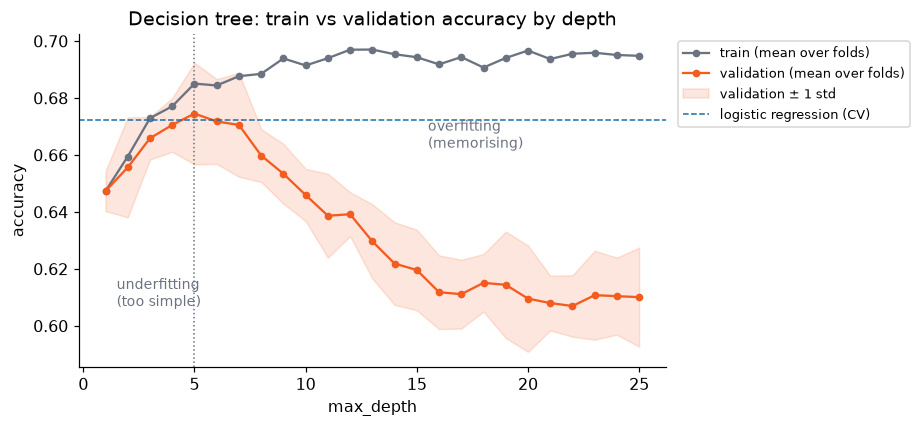

,train,validation,validation_std,gap
max_depth,,,,
1,0.647,0.647,0.007,-0.000
2,0.660,0.656,0.018,0.004
3,0.673,0.666,0.007,0.007
5,0.685,0.675,0.018,0.011
10,0.691,0.646,0.009,0.045
15,0.694,0.620,0.014,0.075
25,0.695,0.610,0.017,0.085


In [20]:
depths = list(range(1, 26))
curve = []
for d in depths:
    tree = {"type": "decision_tree", "params": {"max_depth": d, "random_state": SEED}}
    fs, _ = cross_validate_pipeline(build_pipeline(PREP, tree), X_dev, y_dev, cv, scoring)
    curve.append({"max_depth": d, "train": fs["train"].mean(), "validation": fs["validation"].mean(),
                  "validation_std": fs["validation"].std(ddof=1), "gap": fs["gap"].mean()})
curve = pd.DataFrame(curve).set_index("max_depth")
best_d = curve["validation"].idxmax()

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(curve.index, curve["train"], "o-", color=GRAY, ms=4, label="train (mean over folds)")
ax.plot(curve.index, curve["validation"], "o-", color=ORANGE, ms=4, label="validation (mean over folds)")
ax.fill_between(curve.index, curve["validation"] - curve["validation_std"], curve["validation"] + curve["validation_std"],
                color=ORANGE, alpha=0.15, label="validation ± 1 std")
ax.axhline(baseline["Logistic regression"]["validation"].mean(), color=BLUE, ls="--", lw=1, label="logistic regression (CV)")
ax.axvline(best_d, color=GRAY, ls=":", lw=1)
ax.annotate("underfitting\n(too simple)", xy=(1.5, curve["validation"].min()), fontsize=9, color=GRAY)
ax.annotate("overfitting\n(memorising)", xy=(15.5, curve["validation"].max() - 0.012), fontsize=9, color=GRAY)
ax.set(xlabel="max_depth", ylabel=scoring, title="Decision tree: train vs validation accuracy by depth")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8.5)
plt.tight_layout(); plt.show()
curve.loc[[1, 2, 3, best_d, 10, 15, 25]].round(3)

Reading the two curves:

- **Train** accuracy only goes up with depth: more rules always fit the training rows better.
- **Validation** accuracy rises, peaks at a moderate depth, then *falls* - past the peak, the extra rules describe the training rows' noise, not the population.
- The **gap** is the overfitting signal from week 4, now as a function of one knob. Shallow trees are *biased* (too simple to capture the pattern); deep trees have high *variance* (a different training sample would give a very different tree).

<a class="anchor" id="leaves"></a>
### 2.2 · What a deep tree memorises

The number of leaves, and how many training rows sit in the smallest ones, as the tree grows (fit on the development set, just to look at its structure - no score is computed):

In [21]:
rows = []
for d in [2, 4, 6, 10, 15, None]:
    fitted = build_pipeline(PREP, {"type": "decision_tree", "params": {"max_depth": d, "random_state": SEED}}).fit(X_dev, y_dev)
    t = fitted.named_steps["model"].tree_
    leaf_sizes = t.n_node_samples[t.children_left == -1]
    rows.append({"max_depth": "None (unlimited)" if d is None else d, "actual depth": fitted.named_steps["model"].get_depth(),
                 "leaves": len(leaf_sizes), "median rows per leaf": int(np.median(leaf_sizes)),
                 "leaves with < 5 rows": int((leaf_sizes < 5).sum())})
pd.DataFrame(rows).set_index("max_depth")

,actual depth,leaves,median rows per leaf,leaves with < 5 rows
max_depth,,,,
2,2,4,1078,0
4,4,16,263,0
6,6,60,34,15
10,10,390,4,201
15,15,1427,2,1065
None (unlimited),24,2061,2,1767


An unlimited tree ends with about two thousand leaves, most of them holding one or two people: rules like *"age 23, 2 priors, felony charge → reoffends"* learned from two or three rows. That's what "memorising" means. A shallow tree, by contrast, is small enough to read - here is depth 3, drawn from the fitted pipeline. The feature names come from the preprocessing step, and the thresholds are in its units: robust-scaled numbers, target-encoded categories. (A tree doesn't *need* scaling - splits don't care about units - but it does no harm, and it keeps one preprocessing recipe for every model.)

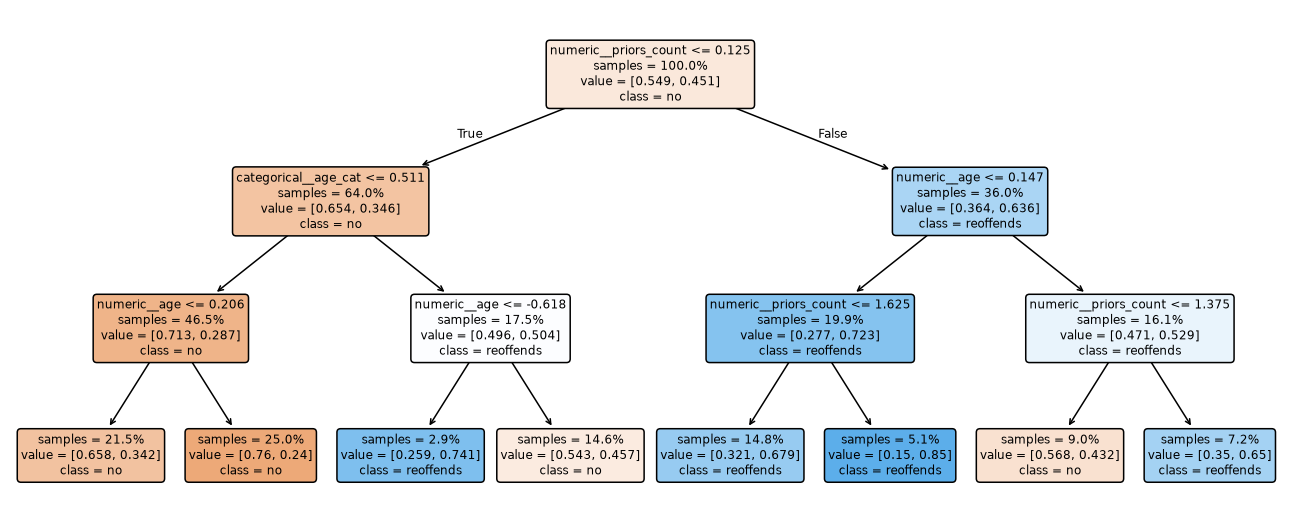

In [22]:
small = build_pipeline(PREP, {"type": "decision_tree", "params": {"max_depth": 3, "random_state": SEED}}).fit(X_dev, y_dev)
fig, ax = plt.subplots(figsize=(15, 6))
plot_tree(small.named_steps["model"], feature_names=small.named_steps["prep"].get_feature_names_out(),
          class_names=["no", "reoffends"], filled=True, impurity=False, proportion=True, rounded=True, fontsize=8, ax=ax)
plt.show()

## <font color='#f35b1f'>3. How Tuning Leaks</font> <a class="anchor" id="leaks"></a>
[Back to TOC](#toc)

<a class="anchor" id="mistakes"></a>
### 3.1 · Three mistakes

Tuning means *trying many candidates and keeping the best*. Every way of doing that wrong has the same root: **the rows that choose the winner are also used to report how good it is.**

| Mistake | What it looks like | Why it's wrong |
|---|---|---|
| **1. Tuning on the test set** | `for d in depths: fit on dev, score on test` → keep the best | the test set has now chosen the model - its score is no longer an unbiased estimate, and there's no untouched data left. **We never do this, not even in a notebook.** |
| **2. Preprocessing outside the folds** | `X_ready = prep.fit_transform(X_dev)` once, then tune the model on `X_ready` | Each candidate is scored on validation rows whose statistics shaped its own features. |
| **3. Reporting the best CV score** | *"tuned tree: 0.68 CV accuracy"* - the best trial's score | even with a perfect pipeline, the best of many noisy scores is **optimistic**. The next section shows why. |

Our pipeline avoids 1 (the test set is locked) and 2 (the `Pipeline` goes into CV whole, in every trial). Mistake 3 needs a new tool: **nested cross-validation**.

<a class="anchor" id="curse"></a>
### 3.2 · The winner's curse

An experiment with **no real differences at all**: 30 "candidates" that are *the same model* (depth-5 tree), each scored by 5-fold CV with a different fold seed. Every candidate is equally good by construction - any difference between their scores is pure luck of the folds selected!

30 identical candidates: mean CV score 0.673, best 0.678, worst 0.666
'Winner' beats the average by +0.005 -- with nothing to win


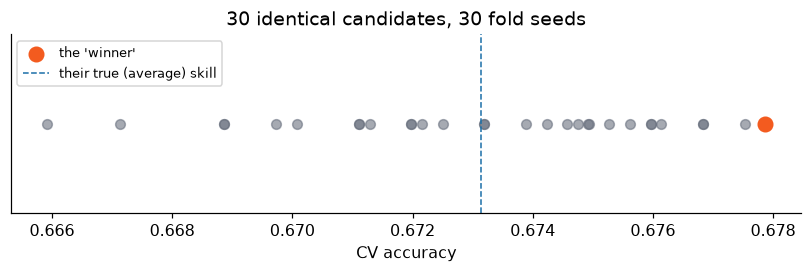

In [23]:
same_model = build_pipeline(PREP, {"type": "decision_tree", "params": {"max_depth": 5, "random_state": SEED}})
luck = np.array([
    cross_val_score(same_model, X_dev, y_dev, cv=StratifiedKFold(5, shuffle=True, random_state=s), scoring=scoring).mean()
    for s in range(30)
])
print(f"30 identical candidates: mean CV score {luck.mean():.3f}, best {luck.max():.3f}, worst {luck.min():.3f}")
print(f"'Winner' beats the average by {luck.max() - luck.mean():+.3f} -- with nothing to win")

fig, ax = plt.subplots(figsize=(7.5, 2.6))
ax.scatter(luck, np.zeros_like(luck), color=GRAY, alpha=0.6, s=40)
ax.scatter([luck.max()], [0], color=ORANGE, s=90, label="the 'winner'")
ax.axvline(luck.mean(), color=BLUE, ls="--", lw=1, label="their true (average) skill")
ax.set_yticks([]); ax.set(xlabel=f"CV {scoring}", title="30 identical candidates, 30 fold seeds")
ax.legend(fontsize=8.5, loc="upper left"); plt.tight_layout(); plt.show()

Picking the maximum picks the luckiest candidate, and its score carries that luck with it. In real tuning the candidates *do* differ, but the same thing happens on top: the winner is partly the best candidate and partly the luckiest. The more candidates you try, and the noisier each score (small data, few folds), the larger the optimism. **The best trial's score is a good way to choose, and a bad way to report.**

## <font color='#f35b1f'>4. Search Strategies and Optuna</font> <a class="anchor" id="optuna"></a>
[Back to TOC](#toc)

Three ways to decide *which* candidates to try:

| Strategy | How it picks the next candidate | Good | Bad |
|---|---|---|---|
| **Grid search** | every combination of listed values | exhaustive, simple | cost explodes with each hyperparameter; wastes trials on unimportant ones |
| **Random search** | random values from each range | same budget covers more distinct values per hyperparameter; easy to parallelise | ignores what earlier trials learned |
| **Bayesian optimisation** (e.g. TPE) | a model of "which regions scored well so far" proposes the next trial | concentrates the budget where it pays off | sequential; more machinery |

scikit-learn's `GridSearchCV` / `RandomizedSearchCV` do the first two, and are leak-free for the same reason our code is: they cross-validate whatever estimator you give them, and we give them the whole `Pipeline`. We will use **Optuna** because it does Bayesian search and handles conditional spaces.


<a class="anchor" id="how-optuna"></a>
### 4.1 · How Optuna works

Optuna runs **one loop, many times**. Each pass of the loop is a **trial** - one candidate set of hyperparameter values, and its score:

![optuna_loop.png](https://miro.medium.com/v2/1*Dcwdkxy9kH1s7EK483py1w.jpeg)

Four words cover all of it:

| Word | What it is | In code |
|---|---|---|
| **study** | the whole search: it runs the loop and remembers every trial | `study = optuna.create_study(direction="maximize", sampler=...)` |
| **trial** | one candidate: a set of values + the score they got | created by the study, handed to your objective |
| **objective** | *your* function: takes a trial, asks it for values (`trial.suggest_int(...)` etc.), builds the candidate, returns its score | `def objective(trial): ... return score` |
| **sampler** | the strategy that decides **which values** each new trial gets | `optuna.samplers.TPESampler(seed=42)` |

Then `study.optimize(objective, n_trials=30)` runs the loop 30 times, and `study.best_params` / `study.best_value` give the winner. That's the whole API we use. The two API boxes below are the only calls to remember:

<div class="alert alert-block alert-info">
<a href='https://optuna.readthedocs.io/en/stable/reference/generated/optuna.create_study.html'>optuna.create_study(direction='minimize', sampler=None, pruner=None, study_name=None, storage=None)</a>

**Definition:**  
Creates a study: the object that runs trials and remembers their results.

**Common Parameters:**  
- `direction`: `'maximize'` or `'minimize'` - sklearn scorers are always *higher is better*, so we maximise
- `sampler`: the search strategy, e.g. `optuna.samplers.TPESampler(seed=42)` or `RandomSampler(seed=42)`
- `pruner`: stops unpromising trials early - needs the objective to report intermediate scores 
</div>

<div class="alert alert-block alert-info">
<a href='https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html'>trial.suggest_int(name, low, high, log=False) · trial.suggest_float(name, low, high, log=False) · trial.suggest_categorical(name, choices)</a>

**Definition:**  
Ask the sampler for one hyperparameter value within the given range.

**Common Parameters:**  
- `name`: the hyperparameter's name - also its column in the results
- `low, high`: the range (both included)
- `log`: sample on a log scale: `min_samples_leaf` from 1 to 200, or `C` from 0.0001 to 100, should give small values as much attention as big ones
- `choices`: the list to pick from, for `suggest_categorical`
</div>

<a class="anchor" id="tpe"></a>
### 4.2 · How TPE chooses the next trial - and how the best is chosen

**TPE** (Tree-structured Parzen Estimator) is Optuna's default sampler. It is a Bayesian strategy: instead of picking values blindly, it **learns from the trials so far** where good values are likely to be. Before each new trial:

1. **Start random.** The first 10 trials (`n_startup_trials=10`) are random - there's nothing to learn from yet.
2. **Split the history in two.** Sort the trials so far by score. The top 10% are "**good**" (with 30 trials: the best 3), the rest are "**bad**".
3. **Draw a smooth curve for each group**, per hyperparameter: $l(x)$ - where the good trials' values sit - and $g(x)$ - where the bad ones sit (a kernel density, the "Parzen estimator").
4. **Propose where good ≫ bad.** It draws 24 candidate values from $l(x)$ and keeps the one with the largest ratio $l(x)/g(x)$: a value that is common among good trials and rare among bad ones.
5. **Run it, add its score to the history, repeat.** Every new score can move the split, so the curves keep updating.

The picture does exactly this with the 30 trials of one run of the tuning in Section 5, for `max_depth` only (your run's trials can differ slightly from computer to computer - the mechanism is the same):

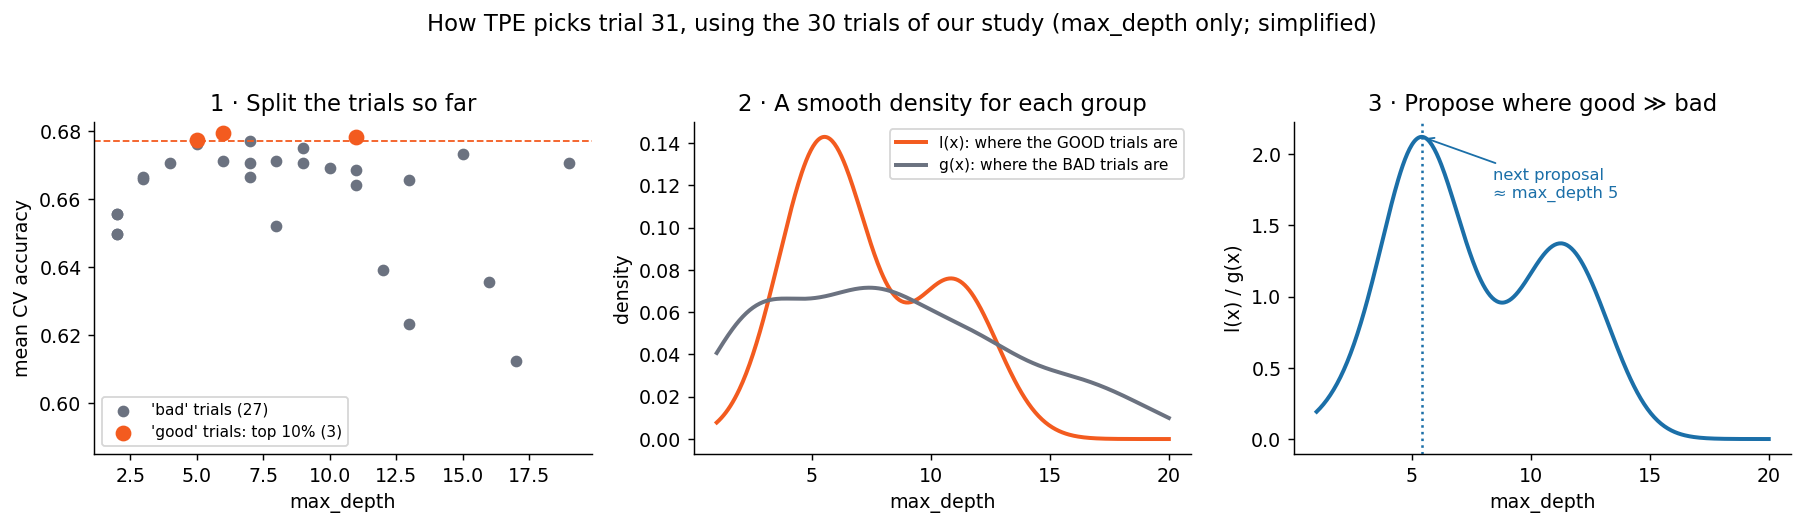

- With the defaults, TPE does this **for each hyperparameter separately** - trial 31 also gets a `min_samples_leaf` and a `criterion` chosen the same way.
- It still **explores**: $l(x)$ is a smooth curve, not a spike, so values near the good ones keep being tried, and a lucky new value can move the split. (*Tree-structured* means it also handles hyperparameters that only exist for some choices - e.g. `max_features` only when the model is a forest.)
- The real sampler is a little more careful than the picture (it adapts the curve widths and adds a weak prior over the whole range), but the idea is exactly this.

<div class="alert alert-block alert-warning">

**TPE does *not* choose the best model.** It only chooses **what to try next**. The best model is chosen by the simplest rule there is: **the trial with the highest mean CV score** (`study.best_trial`). That's a maximum of 30 noisy scores - so, as in Section 3.2, it's a good way to *choose* and an optimistic number to *report*. The honest number comes from nested CV (Section 6).
</div>

<a class="anchor" id="space"></a>
### 4.3 · The search space

**The search space lives in the config**, like every other setting. This is the last new section of `config.yaml` - `tuning`:

In [24]:
# ---- config.yaml -- NEW this week: the tuning section ----
config.update(yaml.safe_load("""
tuning:
  enabled: true
  n_trials: 30
  n_splits: 5                                       # folds that score each candidate
  random_state: 42                                  # seeds the sampler and those folds
  # Keys are Pipeline parameter names. Types: int / float (low, high, log) or categorical (choices).
  search_spaces:
    decision_tree:
      model__max_depth: {type: int, low: 1, high: 20}
      model__min_samples_leaf: {type: int, low: 1, high: 200, log: true}
      model__criterion: {type: categorical, choices: ["gini", "entropy"]}
"""))
search_space = config["tuning"]["search_spaces"][config["model"]["type"]]
pprint(search_space, sort_dicts=False)

{'model__max_depth': {'type': 'int', 'low': 1, 'high': 20},
 'model__min_samples_leaf': {'type': 'int', 'low': 1, 'high': 200, 'log': True},
 'model__criterion': {'type': 'categorical', 'choices': ['gini', 'entropy']}}


The keys are **Pipeline parameter names**: step name, two underscores, parameter. `model__max_depth` is the `max_depth` of the step called `"model"`; `prep__numeric__impute__strategy` would reach inside the preprocessing. `pipeline.set_params(**{"model__max_depth": 6})` applies a dict of them - and the same dict can rebuild the tuned model at any time:

In [25]:
p = build_pipeline(PREP, DT)
print("before:", p.get_params()["model__max_depth"], p.get_params()["model__min_samples_leaf"])
p.set_params(**{"model__max_depth": 6, "model__min_samples_leaf": 101})
print("after: ", p.get_params()["model__max_depth"], p.get_params()["model__min_samples_leaf"])

before: None 1
after:  6 101


## <font color='#f35b1f'>5. Tuning the Tree the Right Way</font> <a class="anchor" id="tuning"></a>
[Back to TOC](#toc)

The rules, all from week 4, now applied to a search:

1. **Development set only** - the test set stays locked.
2. **The objective is CV of the *whole* pipeline**: each trial clones the `Pipeline`, sets the candidate's hyperparameters, and cross-validates it - so the imputer, encoder and scaler are re-fit on the training part of every fold, of every trial.
3. **The same folds for every trial** (`StratifiedKFold` with a fixed `random_state`): candidates are compared like-for-like, the way week 4 compared models.
4. **A seeded sampler**: the same config gives the same study, every run.
5. **Refit the winner on all development rows** - CV chose the hyperparameters; it didn't produce the model.

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.base.clone.html'>sklearn.base.clone(estimator)</a>

**Definition:**  
Returns a new, *unfitted* estimator with the same hyperparameters - so no trial can inherit anything fitted by another.

**Common Parameters:**  
- `estimator`: any sklearn estimator, including a whole `Pipeline`
</div>

#### One trial by hand

Before the function, everything **one trial** does- the loop of Section 4.1, once, on the development set with the tuning folds from the config. We create the trial ourselves with `study.ask()` (normally `study.optimize()` does this) and write the three `suggest_*` calls out in full:

In [26]:
pipeline = build_pipeline(PREP, DT)                      # the pipeline from the config: default hyperparameters
tuning_seed = config["tuning"]["random_state"]
inner_cv = StratifiedKFold(n_splits=config["tuning"]["n_splits"], shuffle=True, random_state=tuning_seed)
study_demo = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=tuning_seed))

# step 1 -- the study opens a trial, and the sampler proposes one value per hyperparameter
trial = study_demo.ask()
params = {
    "model__max_depth": trial.suggest_int("model__max_depth", 1, 20),
    "model__min_samples_leaf": trial.suggest_int("model__min_samples_leaf", 1, 200, log=True),
    "model__criterion": trial.suggest_categorical("model__criterion", ["gini", "entropy"]),
}
print("1. proposed:", params)

# step 2 -- a fresh, UNFITTED copy of the WHOLE pipeline, with those hyperparameters
candidate = clone(pipeline).set_params(**params)
print("2. candidate's max_depth:", candidate.get_params()["model__max_depth"],
      "| the original pipeline's is still:", pipeline.get_params()["model__max_depth"])

# step 3 -- cross-validate the candidate: preprocessing + tree re-fit on the training part of each fold
scores = cross_val_score(candidate, X_dev, y_dev, cv=inner_cv, scoring=scoring)
print("3. fold scores:", scores.round(3), "-> mean", round(scores.mean(), 3))

# step 4 -- tell the study the result; the sampler uses it to choose what to propose next
study_demo.tell(trial, scores.mean())
print("4. trials so far:", len(study_demo.trials))

1. proposed: {'model__max_depth': 8, 'model__min_samples_leaf': 149, 'model__criterion': 'gini'}
2. candidate's max_depth: 8 | the original pipeline's is still: None
3. fold scores: [0.67  0.655 0.685 0.672 0.674] -> mean 0.671
4. trials so far: 1


<div class="alert alert-block alert-success">

<b>New this week → <code>src/tuning.py</code></b><br>
<code>tune_pipeline()</code> - the trial above, packaged in <b>one</b> function. Its inner <code>objective()</code> is steps 1–3: step 1 reads each hyperparameter's range from the search space in the config and calls the matching <code>suggest_int</code> / <code>suggest_float</code> / <code>suggest_categorical</code> (so the ranges are never typed in the code); <code>study.optimize()</code> runs the open → objective → tell loop <code>n_trials</code> times (step 4); the last line builds the winner as an <b>unfitted</b> pipeline. Returns that pipeline and the study.
</div>

In [27]:
# ---- src/tuning.py -- identical to the pipeline ----
def tune_pipeline(pipeline, X, y, cv, scoring: str, search_space: dict, n_trials: int,
                  random_state: int, n_jobs: int = 1):
    """
    Runs an Optuna study (seeded TPE sampler) on (X, y). Each trial draws one value per entry
    of `search_space` (`type`: int / float / categorical; keys are Pipeline parameter names,
    e.g. `model__max_depth`), sets them on a fresh copy of `pipeline`, and returns its mean
    CV score over `cv`.

    Returns (best_pipeline, study): an unfitted copy of `pipeline` with the best trial's
    hyperparameters, and the study with every trial (mean score and fold std).
    """
    def objective(trial):
        params = {}
        for name, spec in search_space.items():
            if spec["type"] == "int":
                params[name] = trial.suggest_int(name, spec["low"], spec["high"], log=spec.get("log", False))
            elif spec["type"] == "float":
                params[name] = trial.suggest_float(name, spec["low"], spec["high"], log=spec.get("log", False))
            elif spec["type"] == "categorical":
                params[name] = trial.suggest_categorical(name, spec["choices"])
            else:
                raise ValueError(f"Unknown search-space type for {name}: {spec['type']}. "
                                 "Options: int, float, categorical")
        candidate = clone(pipeline).set_params(**params)
        scores = cross_val_score(candidate, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs)
        trial.set_user_attr("std", float(scores.std(ddof=1)))
        return scores.mean()

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=random_state))
    study.optimize(objective, n_trials=n_trials)
    best_pipeline = clone(pipeline).set_params(**study.best_params)
    return best_pipeline, study

**What it receives** in `main.py`: the pipeline from `config.yaml`, the development set, the **tuning folds** (`tuning.n_splits`, seeded with `tuning.random_state`), the CV metric, the model's search space and `tuning.n_trials`. Exactly that call:

In [28]:
tuning_config = config["tuning"]
search_space = tuning_config["search_spaces"][config["model"]["type"]]
n_trials = tuning_config["n_trials"]
tuning_seed = tuning_config["random_state"]
inner_cv = StratifiedKFold(n_splits=tuning_config["n_splits"], shuffle=True, random_state=tuning_seed)

t0 = time.time()
best_pipeline, study = tune_pipeline(
    build_pipeline(PREP, DT), X_dev, y_dev, inner_cv, scoring, search_space, n_trials, tuning_seed
)
print(f"\n{n_trials} trials in {time.time() - t0:.0f}s")
print("best hyperparameters:", study.best_params)
print(f"best mean CV score:  {study.best_value:.3f}   <- optimistic (Section 3.2)")


30 trials in 17s
best hyperparameters: {'model__max_depth': 6, 'model__min_samples_leaf': 101, 'model__criterion': 'gini'}
best mean CV score:  0.679   <- optimistic (Section 3.2)


The tuned model, the way `main.py` builds it - the unfitted `best_pipeline`, refit on every development row:

In [29]:
final_model = best_pipeline.fit(X_dev, y_dev)
tree = final_model.named_steps["model"]
print(f"tuned tree: depth {tree.get_depth()}, {tree.get_n_leaves()} leaves "
      f"(the default tree had {build_pipeline(PREP, DT).fit(X_dev, y_dev).named_steps['model'].get_n_leaves()})")

tuned tree: depth 6, 33 leaves (the default tree had 2061)


<div class="alert alert-block alert-info">

**A note on cost.** Each trial re-fits the preprocessing in every fold, even though the preprocessing hyperparameters never change between trials. That's the simple, always-correct version. Larger projects often *cache* it: fit the preprocessing once per fold, store the transformed fold, and let every trial reuse it - still leak-free, because each fold's preprocessing is still fitted on that fold's training rows only. It stops being valid the moment a preprocessing setting is itself tuned, and for us the saving is small, so we keep the simple version (for now).
</div>

## <font color='#f35b1f'>6. Nested Cross-Validation: An Honest Number for a Tuned Model</font> <a class="anchor" id="nested"></a>
[Back to TOC](#toc)

<a class="anchor" id="nested-idea"></a>
### 6.1 · The idea

The tuned model's score is biased because the same folds chose it and scored it. The fix is the week 4 rule once more - **score it on rows that took no part in the decision** - applied to the *whole tuning procedure*:


![ncv.png](https://assets.insightmediagroup.io/media/wp-content/uploads/2024/05/1-HBxFOyusUjpBJ_O-k9tUQ-1.png)

```
development set
└── OUTER fold k = 1..5  (the same 5 folds as cross_validate_pipeline)
    ├── outer-train (80%) ──► tune_pipeline(): an Optuna study, each trial scored by INNER 5-fold CV
    │                         on outer-train only ──► best hyperparameters ──► refit on all outer-train
    └── outer-validation (20%) ──► score it  (these rows never influenced the choice)
```

- The **inner** loop chooses; the **outer** loop judges. The outer-validation fold is to the tuning what the locked test set is to the whole project.
- Five outer folds = five complete, independent tuning runs - each may pick **different** hyperparameters. That's expected: nested CV estimates the **procedure** ("tune a tree with 30 TPE trials, then refit"), not one particular set of hyperparameters.
- The hyperparameters we *keep* still come from Section 5 - the same procedure, run once on all development rows. Nested CV is the honest number to report *for* that procedure.
- **Cost:** 5 outer × 30 trials × 5 inner = 750 fits, plus 150 for the final tuning. A tree takes seconds; a 300-tree forest takes a while.

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.metrics.get_scorer.html'>sklearn.metrics.get_scorer(scoring)</a>

**Definition:**  
Turns a metric name (the same strings `cross_validate` accepts) into a function `scorer(fitted_estimator, X, y)`.

**Common Parameters:**  
- `scoring`: e.g. `'accuracy'`, `'balanced_accuracy'`, `'f1'`, `'roc_auc'`
</div>

<div class="alert alert-block alert-success">

<b>New this week → <code>src/tuning.py</code></b><br>
<code>nested_cross_validate()</code> -  one row per fold in the table (train, validation, gap, the tuning score <code>inner_best</code>, and the hyperparameters chosen) and every row's out-of-fold prediction. Same return format as <code>cross_validate_pipeline()</code>, so the reports downstream work unchanged. 
</div>

In [30]:
# ---- src/tuning.py -- identical to the pipeline ----
def nested_cross_validate(pipeline, X, y, outer_cv, inner_cv, scoring: str, search_space: dict,
                          n_trials: int, random_state: int, n_jobs: int = 1):
    """
    Honest estimate of the tuning procedure. For every outer fold: tune on the outer-training
    rows (`tune_pipeline` with `inner_cv`), refit the best pipeline on them, and score it on
    the outer-validation rows, which took no part in the tuning.

    Returns (fold_scores, y_oof), as `cross_validate_pipeline` does, with two extra kinds of
    columns: `inner_best` (the tuning score inside that fold) and the hyperparameters chosen.
    """
    scorer = get_scorer(scoring)
    rows = []
    y_oof = np.empty(len(X), dtype=np.asarray(y).dtype)
    for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        best_pipeline, study = tune_pipeline(pipeline, X_train, y_train, inner_cv, scoring,
                                             search_space, n_trials, random_state, n_jobs)
        best_pipeline.fit(X_train, y_train)

        train_score = scorer(best_pipeline, X_train, y_train)
        val_score = scorer(best_pipeline, X_val, y_val)
        y_oof[val_idx] = best_pipeline.predict(X_val)
        rows.append({"fold": fold, "train": train_score, "validation": val_score,
                     "gap": train_score - val_score, "inner_best": study.best_value,
                     **study.best_params})
    return pd.DataFrame(rows), y_oof

<a class="anchor" id="nested-run"></a>
### 6.2 · Running it

Exactly the call in `main.py` - the **outer** folds are the pipeline's usual `cv`, the inner ones are the tuning folds:

In [31]:
t0 = time.time()
nested_scores, y_oof_tuned = nested_cross_validate(
    build_pipeline(PREP, DT), X_dev, y_dev, cv, inner_cv, scoring, search_space, n_trials, tuning_seed
)
print(f"nested CV: {time.time() - t0:.0f}s\n")
_ = cv_report(nested_scores, scoring)

nested CV: 35s

Cross-validation (5 stratified folds, metric: accuracy)

 fold  train  validation    gap  inner_best  model__max_depth  model__min_samples_leaf model__criterion
    1  0.681       0.670  0.011       0.678                 8                      149             gini
    2  0.697       0.645  0.052       0.681                13                       35          entropy
    3  0.679       0.679  0.001       0.669                 8                       71          entropy
    4  0.682       0.689 -0.007       0.673                15                       98             gini
    5  0.686       0.679  0.007       0.672                10                       41          entropy

Train       mean = 0.685   std = 0.007
Validation  mean = 0.672   std = 0.017
Gap         mean = +0.013   std = 0.023


Three things to read in this table:

- **`validation`** - the honest estimate of the tuned tree. Its mean ± std is the number that goes in the README.
- **`inner_best` vs `validation`**-— in each fold, what the tuner *believed* (its best trial's score) against what it *got* on unseen rows. The difference is the optimism of Section 3.2, measured.
- **The chosen hyperparameters differ across folds** . If they varied wildly *and* the scores did too, that would be a warning that the tuning is unstable.

The last function writes the final study and this optimism check into the report:

<div class="alert alert-block alert-success">

🆕 <b>New this week → <code>src/tuning.py</code></b><br>
<code>tuning_report()</code> — best hyperparameters and the top trials of the final study, plus the optimism check: mean <code>inner_best</code> vs mean outer <code>validation</code>. Text, printed and saved to <code>results/</code> like the other reports.
</div>

In [32]:
# ---- src/tuning.py -- identical to the pipeline ----
def tuning_report(study, nested_scores: pd.DataFrame, scoring: str = "accuracy", top: int = 5) -> str:
    """
    Best hyperparameters and top trials of the final study, plus the optimism check (mean
    tuning score vs mean honest score over the outer folds), as text (printed and returned).
    """
    trials = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
    trials = trials.rename(columns=lambda c: c.replace("params_", "").replace("user_attrs_", ""))
    trials = trials.rename(columns={"number": "trial", "value": f"mean {scoring}"})
    inner, outer = nested_scores["inner_best"].mean(), nested_scores["validation"].mean()
    lines = [
        f"Tuning on the whole development set ({len(study.trials)} Optuna trials, metric: {scoring})",
        f"Best hyperparameters: {study.best_params}",
        f"Best mean CV score:   {study.best_value:.3f}  (the maximum over all trials -- optimistic)",
        "",
        f"Top {top} trials:",
        trials.sort_values(f"mean {scoring}", ascending=False).head(top)
              .to_string(index=False, float_format=lambda v: f"{v:.3f}"),
        "",
        "Optimism check (nested CV):",
        f"  tuning score inside the outer folds (inner_best) mean = {inner:.3f}",
        f"  honest score on the outer folds (validation)     mean = {outer:.3f}",
        f"  optimism = {inner - outer:+.3f}   -> report the honest one",
    ]
    text = "\n".join(lines)
    print(text)
    return text

In [33]:
_ = tuning_report(study, nested_scores, scoring)

Tuning on the whole development set (30 Optuna trials, metric: accuracy)
Best hyperparameters: {'model__max_depth': 6, 'model__min_samples_leaf': 101, 'model__criterion': 'gini'}
Best mean CV score:   0.679  (the maximum over all trials -- optimistic)

Top 5 trials:
 trial  mean accuracy model__criterion  model__max_depth  model__min_samples_leaf   std
    26          0.679             gini                 6                      101 0.013
    16          0.678             gini                11                      120 0.013
    24          0.678             gini                 5                      109 0.013
    25          0.677             gini                 5                      130 0.013
    29          0.677          entropy                 7                       85 0.013

Optimism check (nested CV):
  tuning score inside the outer folds (inner_best) mean = 0.674
  honest score on the outer folds (validation)     mean = 0.672
  optimism = +0.002   -> report the honest one


## <font color='#f35b1f'>7. Adding Tuning to Your Pipeline</font> <a class="anchor" id="pipeline"></a>
[Back to TOC](#toc)

<div class="alert alert-block alert-warning">

**⚠️ Step 0 - before anything else in your pipeline: update the environment.** This week adds a new package, `optuna`. Without it, `python main.py` stops at `import optuna` with `ModuleNotFoundError`.

1. Add this line to your pipeline's **`requirements.txt`**:
   ```
   optuna>=4.0
   ```
2. From the pipeline's root folder, with the venv **active** (you should see `(venv)` in your prompt), reinstall:
   ```bash
   source venv/bin/activate           # macOS / Linux   (Windows: venv\Scripts\activate)
   pip install -r requirements.txt
   ```
3. Check it worked: `python -c "import optuna; print(optuna.__version__)"`

Do this **every time** a week adds a package to `requirements.txt` - the file lists what the project needs, but only `pip install` actually installs it.
</div>

One new file, and small changes around it. The functions created are copied verbatim into the pipeline (three into `src/tuning.py`, `build_pipeline()` into `src/model.py`); the two new config cells (`model`, `tuning`) are exactly what goes into `config.yaml`. The full list:

| File | Change |
|---|---|
| **`src/tuning.py`** (new) | `tune_pipeline()`, `nested_cross_validate()`, `tuning_report()` - Sections 5–6 |
| `src/model.py` | new `build_pipeline()` (Section 1.4) |
| `config.yaml` | new **`tuning`** section (on/off, `n_trials`, `n_splits`, `random_state`, one search space per model type); `model.type: "decision_tree"` with `random_state: 42` |
| `main.py` | `pipeline = build_pipeline(config["preprocessing"], config["model"])`; after the usual CV: if `tuning.enabled`, run nested CV (its out-of-fold predictions feed the reports), then tune on all development rows, then refit the tuned pipeline — below |
| `src/results.py` | the run header records the tuning settings |
| `requirements.txt` | `optuna>=4.0` - then `pip install -r requirements.txt` again, with your venv active |

The new block in `main.py`, between the CV report and the classification report:

```python
    # week 5: hyperparameter tuning -- on the development set only, every candidate scored by
    # CV of the whole pipeline (see src/tuning.py)
    tuning_config = config.get("tuning", {})
    if tuning_config.get("enabled", False):
        model_type = config["model"]["type"]
        search_spaces = tuning_config.get("search_spaces") or {}
        if model_type not in search_spaces:
            raise ValueError(...)                                  # a clear message instead of a KeyError
        search_space = search_spaces[model_type]
        ...
        inner_cv = StratifiedKFold(n_splits=tuning_config["n_splits"], shuffle=True, random_state=tuning_seed)

        # 1. the honest estimate (its out-of-fold predictions replace the untuned ones)
        nested_scores, y_oof = nested_cross_validate(
            pipeline, X_dev, y_dev, cv, inner_cv, scoring, search_space, n_trials, tuning_seed, n_jobs=n_jobs
        )
        # 2. the hyperparameters we keep: the same procedure, once, on the whole development set
        pipeline, study = tune_pipeline(
            pipeline, X_dev, y_dev, inner_cv, scoring, search_space, n_trials, tuning_seed, n_jobs=n_jobs
        )
```

With `tuning.enabled: false` the pipeline does exactly what it did in week 4. With it on, `python main.py` prints, in order: the default-hyperparameter CV table, the nested CV table, the tuning report with the optimism check, the classification report and fairness audit (from the nested out-of-fold predictions), and the final tuned model. The whole run takes well under a minute for the tree.

# <font color='#f35b1f'>Key Takeaways</font> <a class="anchor" id="takeaways"></a>
[Back to TOC](#toc)

- **Hyperparameters are decisions**, so they're chosen on the development set, by CV of the **whole pipeline**, on the **same folds** for every candidate - never with the test set.
- **`max_depth` is the tree's bias–variance dial**: too shallow underfits, too deep memorises. `min_samples_leaf` is a second brake; together they form a ridge of equally good settings.
- **Grids don't scale.** Random search covers more ground; Bayesian search (Optuna's TPE) learns where to look.
- **The best trial's score is optimistic** - it's the maximum of noisy numbers. Use it to *choose*, never to *report*.
- **Nested CV** gives the honest number for "tune, then refit": the inner loop chooses, the outer loop judges. The final hyperparameters come from tuning once on all development rows.
- The pipeline now does all of this with one command, and the test set is **still** untouched.
- **Anything that learns is a Pipeline step** - imputers, encoders, scalers and the model. `build_pipeline()` is the one place steps are added.

## Update your README (due Saturday 23:59)

Add this week's row to "Pipeline progress", and extend "Model evaluation":

```markdown
### Hyperparameter tuning
How the pipeline tunes (Optuna, search space, number of trials, inner folds) and why it doesn't leak.

| Model | Default: CV mean ± std | Tuned: nested CV mean ± std | Tuning score (best trial) | Optimism | Chosen hyperparameters |
|---|---|---|---|---|---|
| Decision tree | ... | ... | ... | ... | ... |
| Logistic regression | ... | ... | ... | ... | ... |
| Random forest | ... | ... | ... | ... | ... |

3–5 sentences: which models gained from tuning, and is the gain larger than the fold-to-fold std?
Did tuning change which model is best? Which number would you report for your best model, and why?
```

## Challenges

Start with 1 and 2 (they fill the README table); the rest are for going further. For every change, keep the rules: development set only, whole pipeline, same folds.

1. **Tune logistic regression.** Add a `logistic_regression` search space to `config.yaml`. Its main hyperparameter is the regularisation strength `C` (smaller = stronger regularisation): search it on a **log scale**, e.g. 0.0001 to 100. Does tuning help LR as much as it helped the tree? Why might a linear model have less to gain?
2. **Tune the random forest.** Add a `random_forest` search space: `n_estimators`, `max_depth` (include `null` - YAML for `None` - as an option: use `categorical`), `min_samples_leaf`, `max_features` (e.g. `["sqrt", "log2", 0.5, 1.0]`). A forest makes every trial ~100× slower: start with `n_trials: 15`, set `cv.n_jobs: -1`, and keep `n_estimators` modest while tuning. Compare the depth the forest chooses with the depth the tree chose - does it match your answer to Section 2.4?

**Going further**:

3. **Tune the preprocessing too.** Add `prep__numeric__impute__strategy: {type: categorical, choices: ["median", "mean"]}` to the tree's search space. Why is this still leak-free? Would it still be leak-free if the preprocessing were fitted once, outside the trials (the caching note in Section 5)?
4. **Change what "best" means.** Set `cv.scoring` to `"balanced_accuracy"` or `"f1"` and tune again. Do the chosen hyperparameters change? What happens to recall of the positive class, and to the false positive rates in the fairness audit?
